## Build Non-Linear Dataset

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

np.random.seed(42)
n = 1000

# Create circular/non-linear data
# Class 1 (Pass) = students with balanced profile
# Class 0 (Fail) = students at extremes

study   = np.random.uniform(0, 10, n)
prev    = np.random.uniform(0, 100, n)

# Circular boundary — students near the "sweet spot" pass
center_study = 5.0
center_prev  = 60.0

distance = ((study - center_study) ** 2 / 9 +
            (prev  - center_prev)  ** 2 / 400)

# Pass if within the ellipse + some noise
noise     = np.random.normal(0, 0.3, n)
result    = (distance + noise < 1.0).astype(int)

df = pd.DataFrame({
    'study_hours' : study,
    'prev_score'  : prev,
    'result'      : result
})

print("Class distribution:")
print(df['result'].value_counts())

X = df[['study_hours', 'prev_score']].values
y = df['result'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Class distribution:
result
0    829
1    171
Name: count, dtype: int64


## Helper — Plot Decision Boundary

In [11]:
def plot_decision_boundary(model, X, y, title, ax):
    # Create a mesh grid over the feature space
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 5,   X[:, 1].max() + 5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    # Predict on every point in the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot filled contour = decision regions
    ax.contourf(xx, yy, Z, alpha=0.3,
                colors=['coral', 'steelblue'])

    # Plot actual data points
    ax.scatter(X[y==0, 0], X[y==0, 1],
               c='coral',     alpha=0.5, s=20, label='Fail')
    ax.scatter(X[y==1, 0], X[y==1, 1],
               c='steelblue', alpha=0.5, s=20, label='Pass')

    acc = accuracy_score(y, model.predict(X))
    ax.set_title(f"{title}\nAccuracy: {acc:.3f}")
    ax.set_xlabel("Study Hours")
    ax.set_ylabel("Prev Score")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

## Compare Degrees 1 to 5

Degree 1:   2 features, Test Accuracy: 0.825
Degree 2:   5 features, Test Accuracy: 0.910
Degree 3:   9 features, Test Accuracy: 0.950
Degree 4:  14 features, Test Accuracy: 0.960
Degree 5:  20 features, Test Accuracy: 0.955


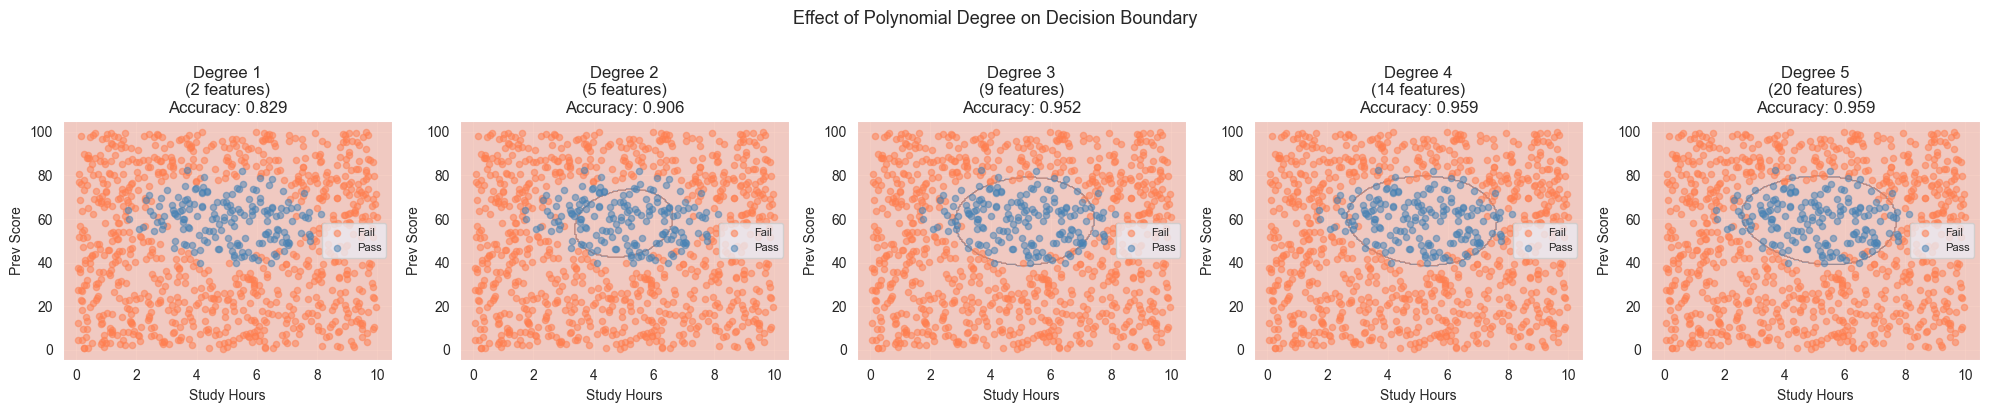

In [12]:
degrees = [1, 2, 3, 4, 5]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, degree in zip(axes, degrees):

    # Pipeline: PolynomialFeatures → Scaler → LogisticRegression
    model = Pipeline([
        ('poly',    PolynomialFeatures(
                        degree          = degree,
                        include_bias    = False
                        # ↑ don't add extra bias column
                        #   LogisticRegression has its own intercept
                    )),
        ('scaler',  StandardScaler()),
        ('lr',      LogisticRegression(
                        C            = 1.0,
                        max_iter     = 1000,
                        random_state = 42
                    ))
    ])

    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))

    # Count how many features were created
    n_features = model.named_steps['poly'].n_output_features_
    print(f"Degree {degree}: {n_features:3d} features, "
          f"Test Accuracy: {test_acc:.3f}")

    plot_decision_boundary(
        model, X, y,
        title = f"Degree {degree}\n({n_features} features)",
        ax    = ax
    )

plt.suptitle("Effect of Polynomial Degree on Decision Boundary",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## What PolynomialFeatures Creates

In [13]:
# See exactly what features are generated
poly = PolynomialFeatures(degree=2, include_bias=False)
poly.fit(X_train)

print("Original features:    ", ['study_hours', 'prev_score'])
print("Polynomial features:  ", poly.get_feature_names_out(
                                     ['study_hours', 'prev_score']))

# Original features:     ['study_hours', 'prev_score']
# Polynomial features:   ['study_hours',
#                          'prev_score',
#                          'study_hours^2',
#                          'study_hours prev_score',
#                          'prev_score^2']
#
# Degree 2 turns 2 features into 5 features
# Degree 3 turns 2 features into 9 features
# With many original features, this EXPLODES quickly:
#   10 features × degree 3 → 286 features!

Original features:     ['study_hours', 'prev_score']
Polynomial features:   ['study_hours' 'prev_score' 'study_hours^2' 'study_hours prev_score'
 'prev_score^2']


## Feature Explosion Warning

In [14]:
# Show how features grow with degree and original feature count
print(f"{'Features':>10} {'Degree 2':>10} {'Degree 3':>10} {'Degree 4':>10}")
print("─" * 45)

for n_feat in [2, 5, 10, 20, 50]:
    counts = []
    for deg in [2, 3, 4]:
        poly  = PolynomialFeatures(degree=deg, include_bias=False)
        dummy = np.zeros((1, n_feat))
        poly.fit(dummy)
        counts.append(poly.n_output_features_)
    print(f"{n_feat:>10}  {counts[0]:>9}  {counts[1]:>9}  {counts[2]:>9}")

#  Features   Degree 2   Degree 3   Degree 4
# ─────────────────────────────────────────────
#         2          5          9         14
#         5         20         55        125
#        10         65        285       1000
#        20        230       1770      12650
#        50       1325      23425     316250   ← dangerous!

  Features   Degree 2   Degree 3   Degree 4
─────────────────────────────────────────────
         2          5          9         14
         5         20         55        125
        10         65        285       1000
        20        230       1770      10625
        50       1325      23425     316250


## Bias-Variance Tradeoff with Degree

Degree 1: CV=0.829 ± 0.002
Degree 2: CV=0.906 ± 0.004
Degree 3: CV=0.949 ± 0.007
Degree 4: CV=0.955 ± 0.008
Degree 5: CV=0.957 ± 0.009
Degree 6: CV=0.959 ± 0.011
Degree 7: CV=0.961 ± 0.009


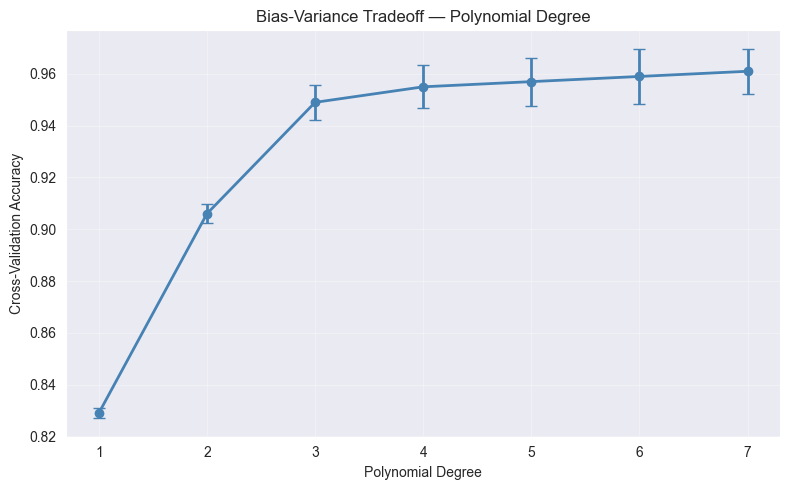

In [15]:
# Cross-validation score vs degree — see overfitting happen
degrees     = range(1, 8)
cv_means    = []
cv_stds     = []

for degree in degrees:
    model = Pipeline([
        ('poly',   PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr',     LogisticRegression(C=1.0, max_iter=1000, random_state=42))
    ])
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f"Degree {degree}: CV={scores.mean():.3f} ± {scores.std():.3f}")

plt.figure(figsize=(8, 5))
plt.errorbar(degrees, cv_means, yerr=cv_stds,
             marker='o', color='steelblue',
             capsize=4, linewidth=2)
plt.xlabel("Polynomial Degree")
plt.ylabel("Cross-Validation Accuracy")
plt.title("Bias-Variance Tradeoff — Polynomial Degree")
plt.xticks(degrees)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Accuracy rises then falls → classic bias-variance curve
# Peak = optimal degree

## Regularization + Polynomial Features

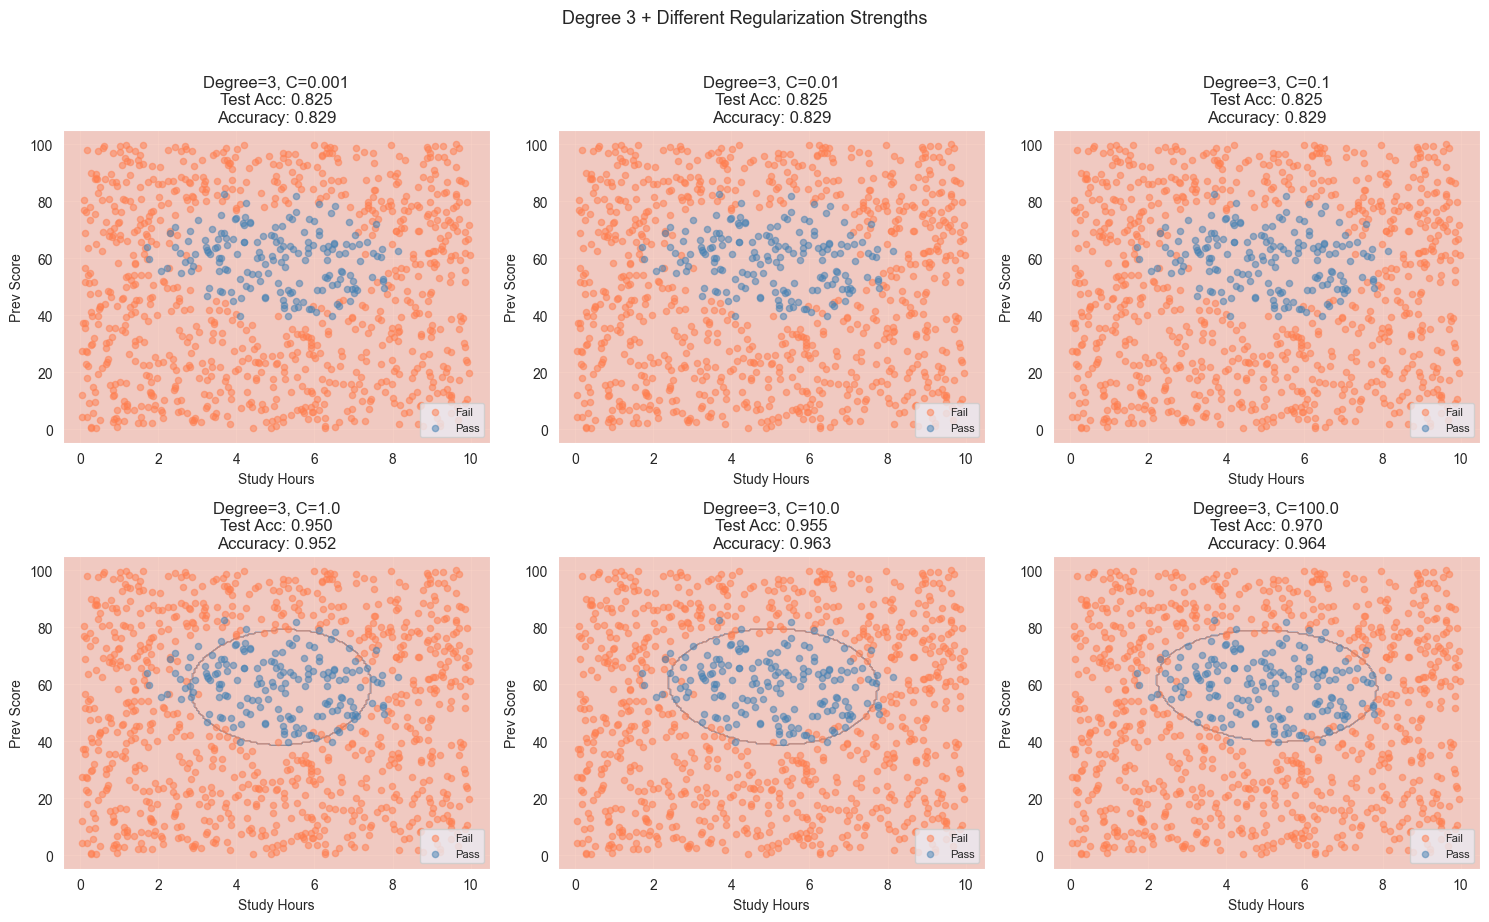

In [16]:
# Higher degree → more features → more likely to overfit
# Solution: combine high degree with STRONG regularization (small C)

degree = 3
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, C in zip(axes, C_values):
    model = Pipeline([
        ('poly',   PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr',     LogisticRegression(C=C, max_iter=1000, random_state=42))
    ])
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))

    plot_decision_boundary(
        model, X, y,
        title=f"Degree={degree}, C={C}\nTest Acc: {test_acc:.3f}",
        ax=ax
    )

plt.suptitle("Degree 3 + Different Regularization Strengths",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Small C (0.001) → very smooth boundary → underfit
# Medium C (0.1)  → good curved boundary → just right
# Large C (100)   → wiggly, complex boundary → overfit